# 드라이브 불러오기

In [202]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 라이브러리 불러오기

In [203]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 데이터 불러오기

In [204]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/spotify_top_songs_with_hit.csv")
print(df.shape) #(데이터(곡) 개수, feature 개수)
df.head(5)


(6513, 24)


,id,artist_names,track_name,source,key,mode,time_signature,danceability,energy,speechiness,...,loudness,tempo,duration_ms,weeks_on_chart,streams,log_streams,streams_z,weeks_z,hit_score,hit
0,000xQL6tZNLJzIrtIgxqSl,"ZAYN, PARTYNEXTDOOR",Still Got Time (feat. PARTYNEXTDOOR),RCA Records Label,G,Major,4 beats,0.748,0.627,0.0639,...,-6.029,120.963,188491,17,107527761,8.031521,0.783822,0.140553,0.462187,0
1,003eoIwxETJujVWmNFMoZy,Alessia Cara,Growing Pains,Def Jam Recordings,C#/Db,Minor,4 beats,0.353,0.755,0.7330,...,-6.276,191.153,193680,2,9944865,6.997599,-0.787647,-0.482266,-0.634956,0
2,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,Island Records,C#/Db,Major,4 beats,0.352,0.911,0.0747,...,-5.230,148.033,222973,125,512388123,8.709599,1.814440,4.624848,3.219644,1
3,00B7TZ0Xawar6NZ00JFomN,"Cardi B, Chance the Rapper",Best Life (feat. Chance The Rapper),Atlantic/KSR,A,Major,4 beats,0.620,0.625,0.5530,...,-7.438,167.911,284856,2,11985346,7.078651,-0.664455,-0.482266,-0.573361,0
4,00Blm7zeNqgYLPtW6zg8cj,"Post Malone, The Weeknd",One Right Now (with The Weeknd),Republic Records,C#/Db,Major,4 beats,0.687,0.781,0.0530,...,-4.806,97.014,193507,30,301860377,8.479806,1.465176,0.680329,1.072752,0


# 불필요한 변수 제거

In [205]:
# 모델에 필요가 없거나 hit에 직접적으로 영향을 주는 변수들 제거
drop_cols = ['id',	'artist_names',	'track_name',	'source',	'key',	'mode',
             'time_signature', 'duration_ms',	'weeks_on_chart',	'streams',	'log_streams',
             'streams_z',	'weeks_z',	'hit_score']

existing_drop_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=existing_drop_cols)

print("Removed columns:", existing_drop_cols)


Removed columns: ['id', 'artist_names', 'track_name', 'source', 'key', 'mode', 'time_signature', 'duration_ms', 'weeks_on_chart', 'streams', 'log_streams', 'streams_z', 'weeks_z', 'hit_score']


# Feature / Target 분리 -> Y = hit, X = 기타 feature

In [206]:
X = df.drop(columns=['hit'])
Y = df['hit']

# Train / Test Split
전체 데이터를 학습용(training set)과 평가용(test set)으로 나눈다.
- training set : 모델이 학습하는 데이터
- test set     : 모델의 일반화 성능(처음 보는 데이터)을 평가하는 데이터

In [207]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,      # 데이터의 20%를 테스트 데이터로 분리
    random_state=0     # 매번 실행해도 같은 방식으로 분리되도록 고정
)

# Decision Tree Classifier 정의 및 학습

In [208]:
model = DecisionTreeClassifier(
    max_depth=8,        # 트리의 최대 깊이를 제한해 과적합(overfitting)을 방지
    random_state=0,     # 트리 생성 시 무작위성이 들어가는 부분(노드 분할 순서)을 고정하여 실행할 때마다 같은 모델 구조가 나오도록 설정
)

model.fit(X_train, Y_train)   # 학습 데이터(X_train, y_train)를 사용하여 모델을 실제로 학습시키는 과정. 여기서 결정 트리가 어떤 feature를 기준으로 분기할지 자동으로 학습함

DecisionTreeClassifier(max_depth=8, random_state=0)

# 모델 평가
classification_report에 나오는 항목

- precision = TP / (TP + FP)
→ 'Hit 예측 중 실제 Hit 비율' (오탐 축소 중요)

- recall (sensitivity) = TP / (TP + FN)
→ '실제 Hit 중 모델이 맞춘 비율' (놓침 줄이기 중요)

- f1-score = 2 * (precision * recall) / (precision + recall)
→ precision과 recall의 조화평균 (불균형 클래스에 유용)

- support = 해당 클래스의 샘플 수

confusion matrix 구성요소
- TN: 실제 Not-Hit를 Not-Hit로 맞춘 수
- FP: 실제 Not-Hit를 Hit로 잘못 예측한 수 (false alarm)

- FN: 실제 Hit를 Not-Hit로 놓친 수 (miss)

- TP: 실제 Hit를 Hit로 맞춘 수

In [209]:
#학습된 모델이 테스트 데이터(X_test)를 보고 hit(1) 또는 not-hit(0)을 예측함
pred = model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(Y_test, pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(Y_test, pred))   # [[TN, FP],
                                        # [FN, TP]] 형태로 출력

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1176
           1       0.20      0.03      0.05       127

    accuracy                           0.89      1303
   macro avg       0.55      0.51      0.50      1303
weighted avg       0.84      0.89      0.86      1303


=== Confusion Matrix ===
[[1160   16]
 [ 123    4]]


# 트리 시각화

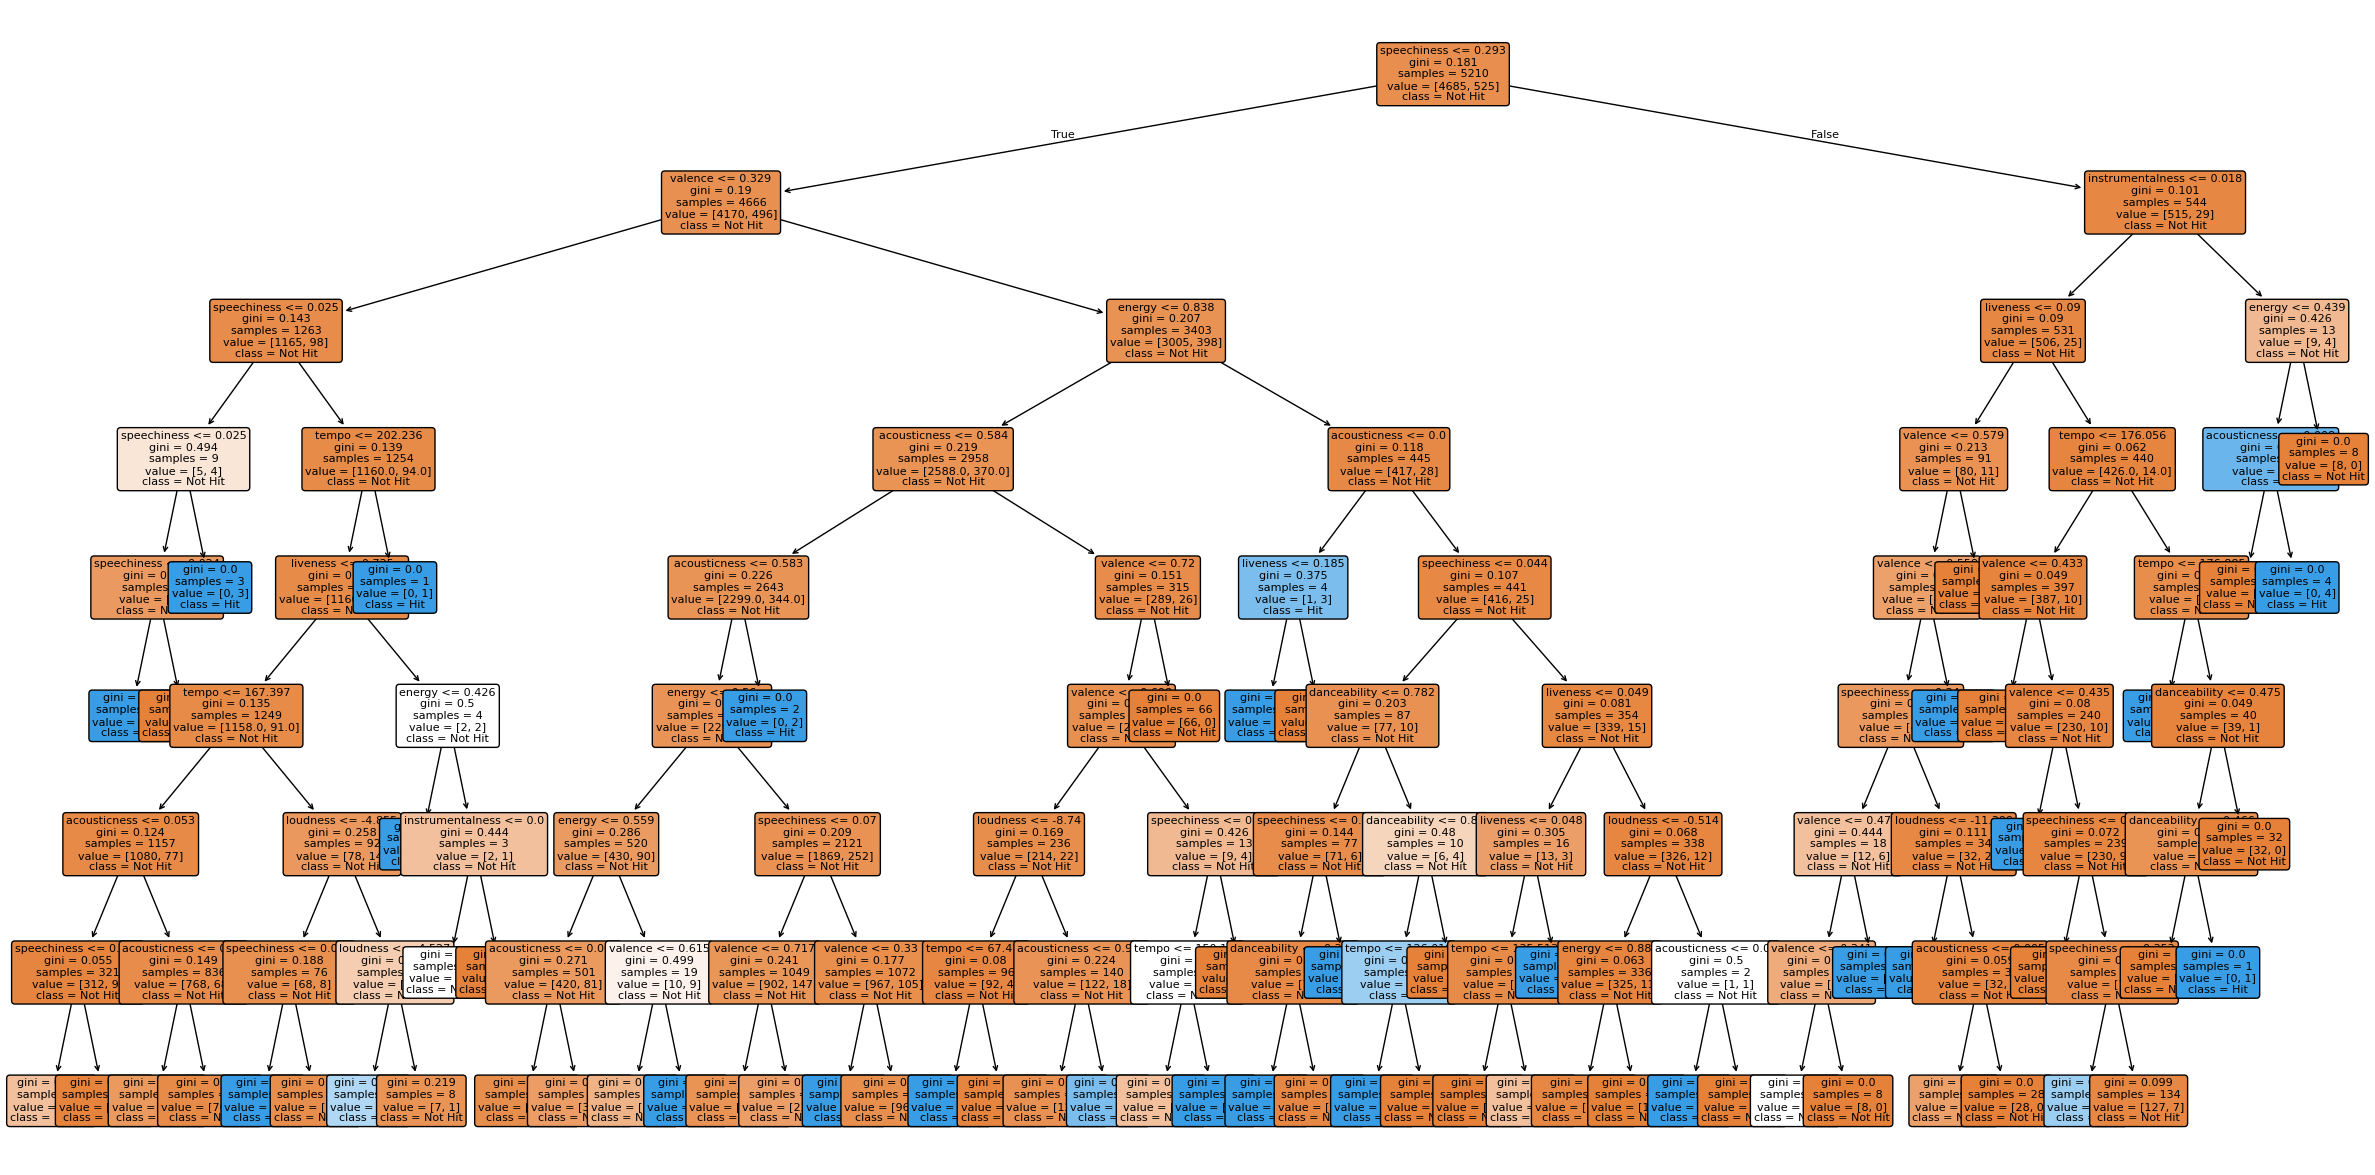

In [210]:
plt.figure(figsize=(30, 15))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Hit', 'Hit'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()


# Feature Importance 분석

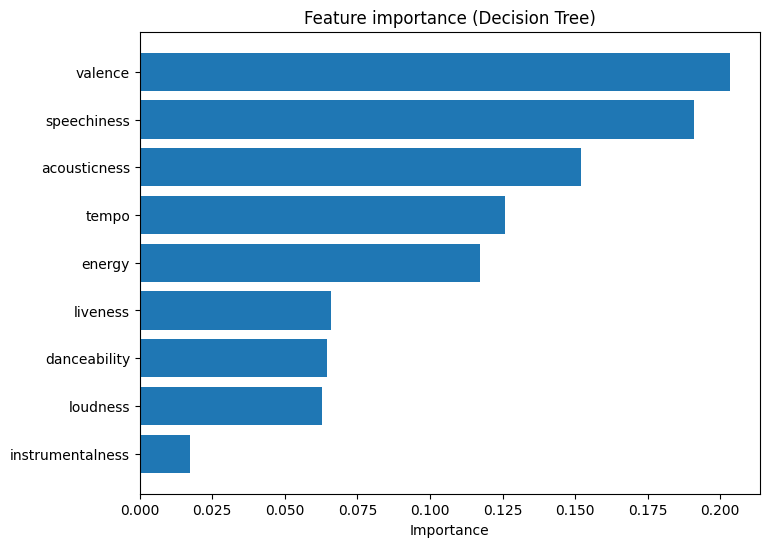


=== Feature Importance ===
            feature  importance
6           valence    0.203454
2       speechiness    0.190932
3      acousticness    0.151925
8             tempo    0.125874
1            energy    0.117281
5          liveness    0.066060
0      danceability    0.064495
7          loudness    0.062723
4  instrumentalness    0.017256


In [211]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df = importance.head(20)  # 상위 20개
plt.figure(figsize=(8,6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature importance (Decision Tree)')
plt.show()

print("\n=== Feature Importance ===")
print(importance)